In [1]:
import pandas as pd
# Visualize tools
import matplotlib.pyplot as plt
import seaborn as sns

# Tools lib for Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Tool to handle imbalanced 
from imblearn.over_sampling import SMOTE

# Save models
import joblib
import warnings
# Hide unimportant noti
warnings.filterwarnings('ignore') 

import numpy as np

# STEP 1: LOAD CLEAN DATA

In [2]:
# Load the cleaned dataset
df = pd.read_csv("../data/processed/SurveilDrone_Net23_DSS_cleaned.csv")
print("1. Distribution of the original label (object_detected):")
print(df['object_detected'].value_counts(normalize=True) * 100)

print("\n2. Distribution of the custom operational label (recommended_action):")
print(df['recommended_action'].value_counts(normalize=True) * 100)

1. Distribution of the original label (object_detected):
object_detected
0    69.999857
1    30.000143
Name: proportion, dtype: float64

2. Distribution of the custom operational label (recommended_action):
recommended_action
Continue Mission    81.923768
Return to Base      18.075519
Delay Mission        0.000713
Name: proportion, dtype: float64


# 2. Feature Selection and Train/Test Split

In this step, we select the top operational variables that heavily influence flight safety and feasibility. The dataset is then divided into a Training set (80%) and a Testing set (20%). 

We utilize the `stratify=y` parameter to ensure that the proportions of our updated target classes are equally represented in both the training and testing phases.

In [3]:
# Define the updated operational safety rules
conditions = [
    (df['battery_level_pct'] < 20) | ((df['battery_level_pct'] < 30) & (df['distance_to_base_m'] > 1500)), # Return to Base condition
    (df['wind_speed_mps'] >= 6.5) # Delay Mission condition (relaxed threshold to match operational reality)
]

# Corresponding labels for the conditions above
choices = ['Return to Base', 'Delay Mission']

# Overwrite the recommended_action column with the new rules; default to Continue Mission if no conditions are met
df['recommended_action'] = np.select(conditions, choices, default='Continue Mission')

# Verify the updated label distribution
print("UPDATED CUSTOM LABEL DISTRIBUTION (recommended_action):")
print(df['recommended_action'].value_counts())
print("\nPercentage (%):")
print(df['recommended_action'].value_counts(normalize=True) * 100)

UPDATED CUSTOM LABEL DISTRIBUTION (recommended_action):
recommended_action
Continue Mission    98083
Return to Base      41206
Delay Mission         967
Name: count, dtype: int64

Percentage (%):
recommended_action
Continue Mission    69.931411
Return to Base      29.379135
Delay Mission        0.689454
Name: proportion, dtype: float64


In [4]:
# Define independent variables (Features - X)
features = [
    'battery_level_pct', 
    'wind_speed_mps', 
    'flight_time_s', 
    'distance_to_base_m', 
    'speed_mps', 
    'altitude_m'
]
X = df[features]

# Define the dependent variable (Target - y)
y = df['surveillance_pattern']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Number of Training samples: {X_train.shape[0]}")
print(f"Number of Testing samples: {X_test.shape[0]}")

Number of Training samples: 112204
Number of Testing samples: 28052


# 3. Handling Imbalanced Data with SMOTE

Although the updated rules resolved the extreme class imbalance, 'Continue Mission' remains the majority class. Training a model directly on this imbalanced distribution can lead to biased predictions. 

To resolve this, we apply the **Synthetic Minority Over-sampling Technique (SMOTE)**. SMOTE generates new synthetic data points for the minority classes. 

**Note:** SMOTE is ONLY applied to the Training set (`X_train`, `y_train`) to prevent data leakage. The Testing set (`X_test`) must remain untouched to accurately evaluate real-world performance.

In [5]:
print("Class distribution BEFORE applying SMOTE (Training Set):")
print(y_train.value_counts())

# Initialize and apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nClass distribution AFTER applying SMOTE (Training Set):")
print(y_train_resampled.value_counts())

Class distribution BEFORE applying SMOTE (Training Set):
surveillance_pattern
Patrol    56155
Hover     16588
Scan      11369
Track     11326
Return     5664
Circle     5576
Idle       5526
Name: count, dtype: int64

Class distribution AFTER applying SMOTE (Training Set):
surveillance_pattern
Track     56155
Patrol    56155
Scan      56155
Hover     56155
Circle    56155
Idle      56155
Return    56155
Name: count, dtype: int64


# 4. Training the Baseline Model: Decision Tree Classifier

The first model we deploy is a Decision Tree. This acts as our "White-box" baseline model because its IF-THEN rules are highly interpretable for operations engineers. We set `max_depth=10` to prevent the tree from growing excessively deep, which mitigates overfitting.

In [6]:
# Initialize the Decision Tree algorithm
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

# Train the model on the balanced dataset
dt_model.fit(X_train_resampled, y_train_resampled)

# Generate predictions on the Testing set
y_pred_dt = dt_model.predict(X_test)

print("CLASSIFICATION REPORT: DECISION TREE (BASELINE)")
print(classification_report(y_test, y_pred_dt))

CLASSIFICATION REPORT: DECISION TREE (BASELINE)
              precision    recall  f1-score   support

      Circle       0.05      0.10      0.06      1394
       Hover       0.14      0.01      0.02      4147
        Idle       0.05      0.01      0.02      1382
      Patrol       0.50      0.41      0.45     14039
      Return       0.05      0.35      0.09      1416
        Scan       0.09      0.10      0.10      2842
       Track       0.12      0.01      0.02      2832

    accuracy                           0.24     28052
   macro avg       0.14      0.14      0.11     28052
weighted avg       0.30      0.24      0.25     28052



# 5. Training the Ensemble Model: Random Forest Classifier

A single Decision Tree is prone to high variance, especially with noisy sensor data. To improve robustness, we utilize a Random Forest Classifier. This ensemble method creates 100 independent decision trees (`n_estimators=100`) and aggregates their predictions via majority voting. This significantly enhances the model's performance, particularly the Recall metric, which is critical for identifying high-risk flight scenarios.

In [ ]:
# Initialize the Random Forest algorithm
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)

# Train the model
rf_model.fit(X_train_resampled, y_train_resampled)

# Generate predictions on the Testing set
y_pred_rf = rf_model.predict(X_test)

print("CLASSIFICATION REPORT: RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))

# 6. Explainable AI (XAI) - Feature Importance Analysis

A Decision Support System cannot operate as a complete "Black-box". We must extract the `feature_importances_` parameter from the Random Forest model to verify its decision-making logic. If the following chart aligns with domain knowledge (e.g., Battery and Wind Speed being the most critical factors), the model is deemed reliable for operational deployment.

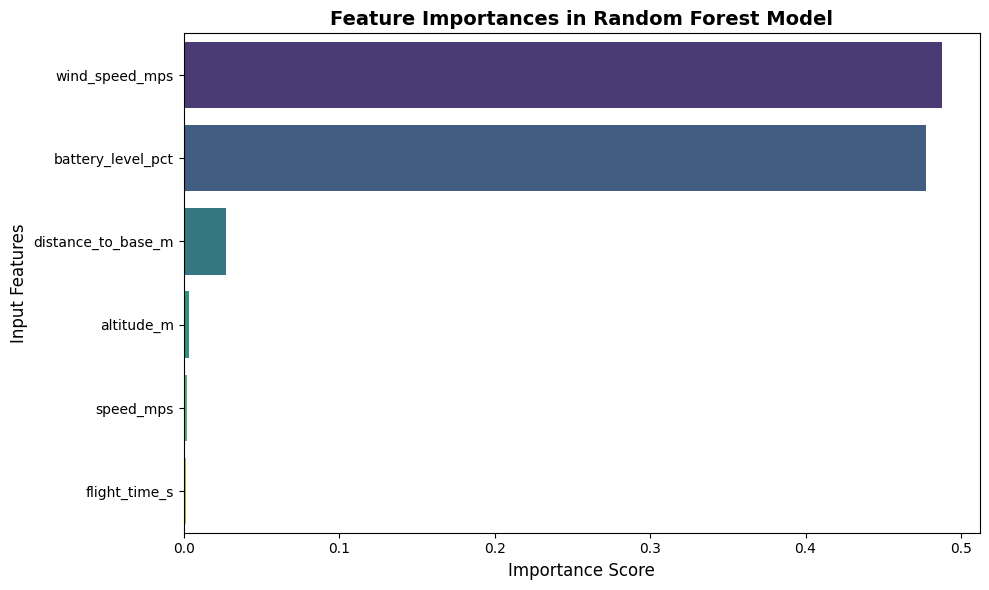

In [ ]:
# Extract feature importance scores
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualize the importances using a horizontal bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('Feature Importances in Random Forest Model', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Input Features', fontsize=12)
plt.tight_layout()
plt.show()

# 7. Model Export for Dashboard Integration

The optimal Random Forest model is exported as a binary Pickle file. This file will be deployed as the underlying recommendation engine for the interactive dashboard in Phase 4.

In [ ]:
# Export the trained model
joblib.dump(rf_model, 'drone_rf_model_v1.pkl', compress=3)
print("Model successfully exported as: drone_rf_model_v1.pkl")

# End of Phase 3 Model Prototype Notebook.

Model successfully exported as: drone_rf_model_v1.pkl
